In [1]:
import matplotlib as mpl
mpl.rcParams['figure.dpi'] = 200
mpl.rcParams['savefig.dpi'] = 300

In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

from bluemath_tk.datamining.lhs import LHS 
from bluemath_tk.datamining.mda import MDA

In [3]:
tracks_input = "outputs/syntetic_tracks_7r_params.csv"

tracks_input_df = pd.read_csv(tracks_input)
tracks_input_df = tracks_input_df.drop(columns=tracks_input_df.columns[0])
tracks_input_df = tracks_input_df.dropna()
tracks_input_df

,azimuth_entrance,distance_entrance,azimuth_exit,distance_exit,azimuth_furthest,distance_furthest_km,p_furthest_hPa,p_entrance_hPa,p_exit_hPa,vmean_entrance_kmh,vmean_furthest_kmh,vmean_exit_kmh
0,177.719087,773.901253,48.566770,760.071837,89.739119,412.106890,1000.299621,994.470343,1003.972938,43.128626,53.152029,51.855053
1,143.132065,763.772384,77.196057,752.395017,108.099855,611.664535,1006.934131,1005.751253,1007.499586,41.702667,56.359839,73.505913
2,242.046138,764.523754,337.078755,760.723750,255.426095,550.708001,1009.992257,1008.344215,1013.131241,52.355686,52.330823,56.621322
3,200.761073,772.267422,109.908886,773.186746,218.492458,424.063107,1006.707026,1004.102245,1007.827385,15.652328,11.475800,13.395999
4,151.695460,754.535602,73.166860,761.730646,136.280703,553.340763,958.586550,953.153471,954.880882,30.233394,36.291348,60.409235
...,...,...,...,...,...,...,...,...,...,...,...,...
13179,239.226643,768.013004,337.842416,178.783764,223.955308,432.907076,1011.083223,1010.288755,1013.443706,45.280196,9.623877,26.320195
13180,237.226297,749.173529,53.615454,766.119864,60.522525,490.658479,1012.199768,1006.393286,1012.401104,25.096406,71.336059,44.782570
13181,170.842094,756.433455,51.198805,764.234725,162.697444,525.461469,977.691633,984.755140,977.284923,34.249932,49.208074,112.936411
13182,252.052355,776.409297,172.819014,464.038743,226.793577,454.642026,1013.217366,1012.250534,1013.474759,38.227003,36.932411,32.605414


In [4]:
hist_tracks_input = "outputs/hist_tracks_7r_params.csv"

hist_df = pd.read_csv(hist_tracks_input)
hist_df = hist_df.drop(columns=hist_df.columns[0:2])
hist_df = hist_df.drop(columns=hist_df.columns[-1])
hist_df = hist_df.dropna()
hist_df

,azimuth_entrance,distance_entrance,azimuth_exit,distance_exit,azimuth_furthest,distance_furthest_km,p_furthest_hPa,p_entrance_hPa,p_exit_hPa,vmean_entrance_kmh,vmean_furthest_kmh,vmean_exit_kmh
0,144.577111,777.409262,114.981312,778.762420,118.798681,758.371069,990.0,988.0000,990.6667,30.767686,26.393547,28.625592
1,164.809081,574.015182,47.943484,769.925676,122.867272,552.054640,995.0,1004.0000,982.3333,17.305947,10.190970,13.432885
2,221.903226,736.561023,49.478402,710.329099,221.700782,309.676951,992.0,993.1667,991.3333,30.027733,35.817289,76.422727
3,158.063269,773.214402,331.060320,241.230427,109.636774,465.295141,1003.0,1003.0000,1015.0000,28.768715,7.852407,27.999378
4,215.295295,771.902862,55.282280,773.707819,240.501169,308.470328,1003.0,993.6667,992.0000,3.980744,8.090314,66.488446
...,...,...,...,...,...,...,...,...,...,...,...,...
167,153.447994,774.942204,29.911950,772.499303,8.784911,640.345891,1005.0,997.0000,1006.1667,24.898282,11.421644,11.724931
168,275.775618,779.816505,36.960953,747.096418,322.977840,421.224910,999.0,1000.0000,997.0000,36.589293,46.986360,41.268198
169,227.556256,752.338144,114.171713,586.474275,158.577067,404.496999,1005.0,1005.0000,1006.0000,43.642132,40.467730,28.608625
170,168.836683,632.851509,66.769067,756.898689,175.154252,301.118794,1011.0,1011.0000,1001.6667,20.017012,17.293533,31.375689


In [5]:
mda_parameters = {"num_centers": 4000}

var_names = list(tracks_input_df.columns)


mda = MDA(num_centers=mda_parameters.get("num_centers"))
mda.logger.disabled = True
mda.fit(data=tracks_input_df, normalize_data = True)

In [6]:
def Plot_Centroids(lhs_df, hist_df, mda_df,case_df, var_names):

    n_vars = len(var_names)

    fig, axes = plt.subplots(
        n_vars - 1,
        n_vars - 1,
        figsize=(3 * (n_vars - 1), 3 * (n_vars - 1)),
    )

    for c1, v1 in enumerate(var_names[1:]):
        for c2, v2 in enumerate(var_names[:-1]):
            if c1 >= c2:
                axes[c2, c1].scatter(
                    lhs_df[v1], lhs_df[v2],
                    c="k", s=2, zorder=1
                )
                axes[c2, c1].scatter(
                    mda_df[v1], mda_df[v2],
                    c="r", s=2, zorder=2
                )
                axes[c2, c1].scatter(
                    hist_df[v1], hist_df[v2],
                    c="blue", s=2, zorder=3
                )
                axes[c2, c1].scatter(
                    case_df[v1], case_df[v2],
                    c="lime", s=50, zorder=4
                )

                axes[c2, c1].set_xlabel(v1)
                axes[c2, c1].set_ylabel(v2)

                if c1 > c2:
                    axes[c2, c1].set_xticks([])
                    axes[c2, c1].set_yticks([])
                    axes[c2, c1].set_xlabel("")
                    axes[c2, c1].set_ylabel("")
            else:
                axes[c2, c1].axis("off")

    legend_handles = [
        Line2D([], [], marker="o", linestyle="None", color="blue",
               markersize=6, label="Historical cases"),
        Line2D([], [], marker="o", linestyle="None", color="k",
               markersize=6, label="Synthetical cases"),
        Line2D([], [], marker="o", linestyle="None", color="r",
               markersize=6, label="MDA selection (1000 centers)"),
        Line2D([], [], marker="o", linestyle="None", color="lime",
               markersize=6, label="Example case (case 13139)"),
    ]

    fig.legend(
        handles=legend_handles,
        loc="center left",
        bbox_to_anchor=(0.2, 0.5),
        frameon=True,
        fontsize=20,
    )

    return fig, axes

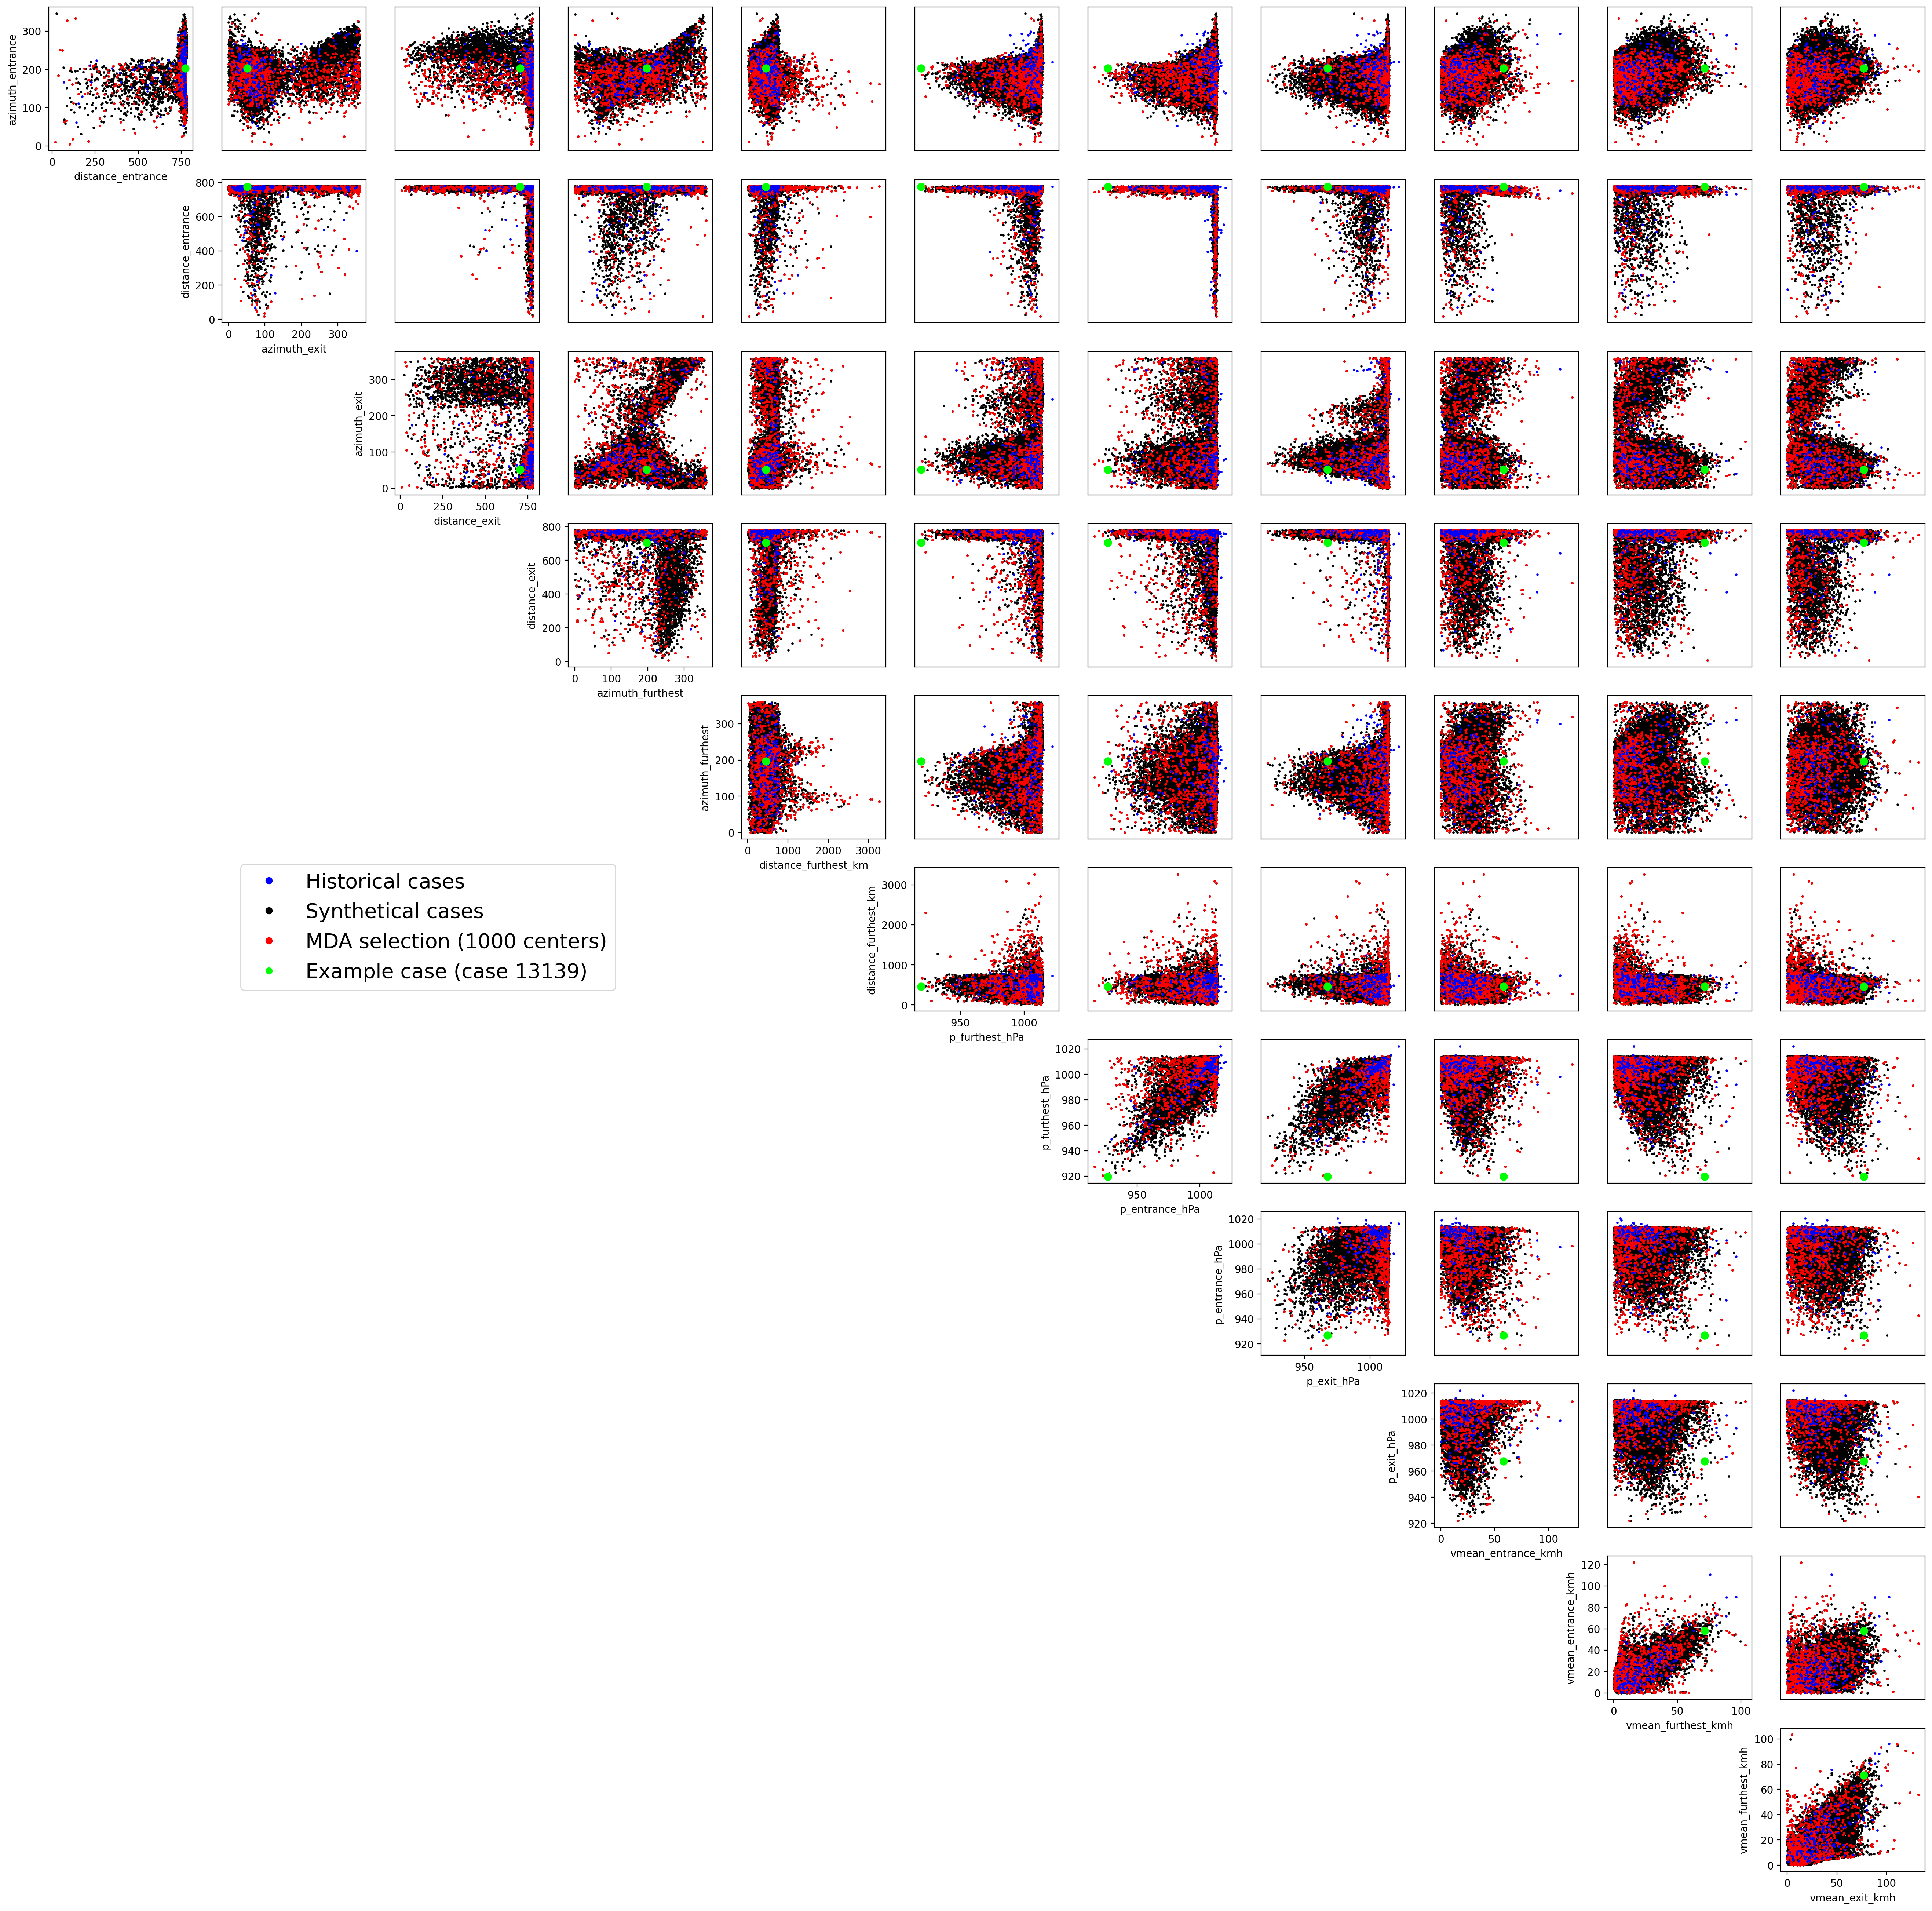

In [7]:
fig, ax = Plot_Centroids(tracks_input_df,hist_df,mda.centroids[:1000],mda.centroids[mda.centroid_real_indices == 13139] ,var_names)
fig.savefig("figures/Syntesis/04_MDA_Centroids_7r_params_furpoint_1.png", bbox_inches="tight", dpi=600)


In [8]:
print(f"{len(mda.centroid_real_indices)} cases selected by MDA.")
print(f"{len(np.unique(mda.centroid_real_indices)) - len(mda.centroid_real_indices)} duplicates found among selected cases.")

4000 cases selected by MDA.
0 duplicates found among selected cases.


In [9]:
mda.save_model(model_path="outputs/mda_model.pkl")

selected_cases = mda.centroid_real_indices
np.savetxt("outputs/selected_cases_MDA_1.csv", selected_cases, fmt="%s", delimiter=",")